In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plt_config

In [7]:
try:
    x0 = np.load("../scripts/variables/x0_00.npy")
    inputs = np.load("../scripts/variables/inputs_00.npy")
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


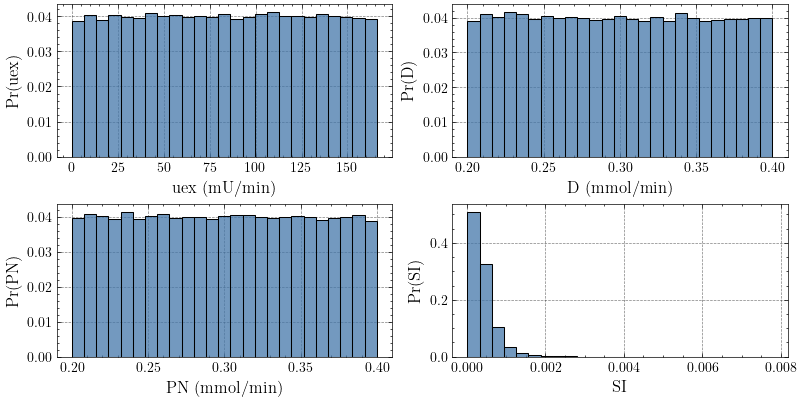

In [8]:
states = [
    "BG (mmol/L)",
    "I (mU/L)",
    "Q (mu/L)",
    "P1 (mmol)",
    "P2 (mmol)",
    "P (mmol)",
    "uen (mU/min)",
]
states_short = ["BG", "I", "Q", "P1", "P2", "P", "uen"]
input_labels = ["uex (mU/min)", "D (mmol/min)", "PN (mmol/min)", "SI"]
input_short = ["uex", "D", "PN", "SI"]
fig, axs = plt.subplots(2,2, figsize=(8,4))
for i in range(inputs.shape[0]):
    idx = np.unravel_index(i, (2,2))
    sns.histplot(data=inputs[i, :], bins=25, stat="probability", ax=axs[idx])
    axs[idx].set_xlabel(input_labels[i])
    axs[idx].set_ylabel(f"Pr({input_short[i]})")
fig.savefig("figures/5_1.pdf", format="pdf")

# fig, ax = plt.subplots()
# sns.histplot(data=np.log(inputs[-1, :]), bins=50, stat="probability", ax=ax)
# ax.set_xlabel("ln SI")
# ax.set_ylabel("Pr(ln SI)")
# fig.savefig("figures/5_5.pdf", format="pdf")

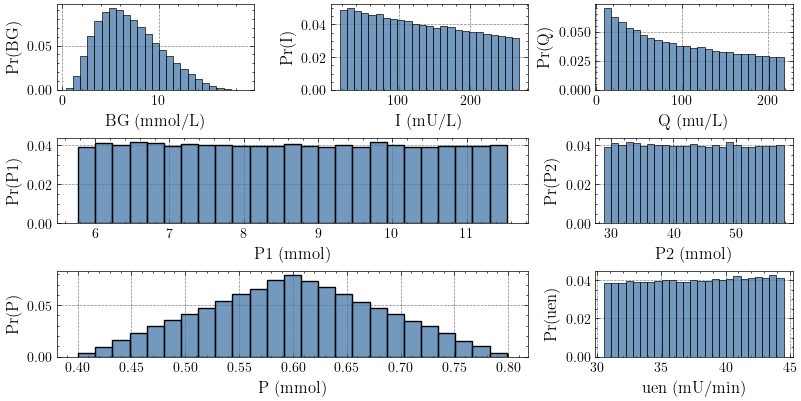

In [9]:
fig = plt.figure(constrained_layout=True, figsize=(8,4))
gs = fig.add_gridspec(nrows=3, ncols=3, height_ratios=[1,1,1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0:2])  
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, 0:2]) 
ax7 = fig.add_subplot(gs[2, 2])

for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7], start=0):
    sns.histplot(data=x0[i, :], bins=25, stat="probability", ax=ax)
    ax.set_xlabel(states[i])
    ax.set_ylabel(f"Pr({states_short[i]})")
plt.show()
fig.savefig("figures/5_2.pdf", format="pdf")

In [10]:
print("Mean initial states: ", np.mean(x0, axis=1))
print("Initial Covariance: \n", np.diag(np.cov(x0, rowvar=True, bias=False)))

Mean initial states:  [  6.997877   133.28167042  98.31990277   8.64481763  43.22408814
   0.59934938  37.63751189]
Initial Covariance: 
 [1.02278123e+01 5.21417490e+03 3.71232176e+03 2.78032838e+00
 6.95082095e+01 6.66200348e-03 1.62970774e+01]
